In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, GridSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, auc, confusion_matrix, classification_report, ConfusionMatrixDisplay
)
from sklearn.calibration import CalibratedClassifierCV
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("✓ All imports successful!")

✓ All imports successful!


In [8]:
# Load exported splits from Data Preparation notebook
SPLITS_PATH = 'splits.joblib'
splits = joblib.load(SPLITS_PATH)

print("Splits structure:")
for split_name, split_data in splits.items():
    print(f"  {split_name}:")
    print(f"    X shape: {split_data['X'].shape}")
    print(f"    y shape: {split_data['y'].shape}")
    print(f"    y value counts:\n{split_data['y'].value_counts()}\n")

# Extract into readable variables
X_train, y_train = splits['train']['X'], splits['train']['y']
X_val, y_val = splits['val']['X'], splits['val']['y']
X_test, y_test = splits['test']['X'], splits['test']['y']

print("✓ Data loaded successfully!")

Splits structure:
  train:
    X shape: (9555, 13)
    y shape: (9555,)
    y value counts:
churn
1    4778
0    4777
Name: count, dtype: int64

  val:
    X shape: (3185, 13)
    y shape: (3185,)
    y value counts:
churn
0    1593
1    1592
Name: count, dtype: int64

  test:
    X shape: (3186, 13)
    y shape: (3186,)
    y value counts:
churn
0    1593
1    1593
Name: count, dtype: int64

✓ Data loaded successfully!


In [9]:
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test, model_name="Model"):
    """
    Evaluate a trained model on train/val/test sets and return metrics.
    """
    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_test_pred = model.predict(X_test)
    
    # Probabilities (for ROC-AUC)
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_val_proba = model.predict_proba(X_val)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    results = {
        'Model': model_name,
        'Train Accuracy': accuracy_score(y_train, y_train_pred),
        'Val Accuracy': accuracy_score(y_val, y_val_pred),
        'Test Accuracy': accuracy_score(y_test, y_test_pred),
        'Train ROC-AUC': roc_auc_score(y_train, y_train_proba),
        'Val ROC-AUC': roc_auc_score(y_val, y_val_proba),
        'Test ROC-AUC': roc_auc_score(y_test, y_test_proba),
        'Test Precision': precision_score(y_test, y_test_pred),
        'Test Recall': recall_score(y_test, y_test_pred),
        'Test F1': f1_score(y_test, y_test_pred),
    }
    
    return results, y_test_pred, y_test_proba

def print_results(results):
    for key, value in results.items():
        if isinstance(value, str):
            print(f"  {key}: {value}")
        else:
            print(f"  {key}: {value:.4f}")

print("✓ Evaluation function created!")

✓ Evaluation function created!


In [11]:
print("=" * 60)
print("BASELINE: LOGISTIC REGRESSION")
print("=" * 60)

# Train
lr_model = LogisticRegression(
    random_state=RANDOM_SEED,
    max_iter=1000,
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)

# Evaluate
lr_results, lr_pred, lr_proba = evaluate_model(
    lr_model, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="Logistic Regression"
)

print("\nLogistic Regression Results:")
print_results(lr_results)

# Confusion Matrix
print("\nConfusion Matrix on Test Set:")
cm = confusion_matrix(y_test, lr_pred)
print(cm)

BASELINE: LOGISTIC REGRESSION

Logistic Regression Results:
  Model: Logistic Regression
  Train Accuracy: 0.7516
  Val Accuracy: 0.7422
  Test Accuracy: 0.7467
  Train ROC-AUC: 0.8265
  Val ROC-AUC: 0.8210
  Test ROC-AUC: 0.8260
  Test Precision: 0.7638
  Test Recall: 0.7144
  Test F1: 0.7382

Confusion Matrix on Test Set:
[[1241  352]
 [ 455 1138]]


In [12]:
print("\n" + "=" * 60)
print("ADVANCED MODELS: Random Forest, XGBoost, LightGBM")
print("=" * 60)

# Random Forest
print("\n[1/3] Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight='balanced'  # Handle any minor imbalance
)
rf_model.fit(X_train, y_train)
rf_results, rf_pred, rf_proba = evaluate_model(
    rf_model, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="Random Forest"
)
print("✓ Random Forest trained")

# XGBoost
print("[2/3] Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_results, xgb_pred, xgb_proba = evaluate_model(
    xgb_model, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="XGBoost"
)
print("✓ XGBoost trained")

# LightGBM
print("[3/3] Training LightGBM...")
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    is_unbalance=True,  # Handle imbalance
    verbose=-1
)
lgb_model.fit(X_train, y_train)
lgb_results, lgb_pred, lgb_proba = evaluate_model(
    lgb_model, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="LightGBM"
)
print("✓ LightGBM trained")

print("\n✓ All models trained!")


ADVANCED MODELS: Random Forest, XGBoost, LightGBM

[1/3] Training Random Forest...
✓ Random Forest trained
[2/3] Training XGBoost...
✓ XGBoost trained
[3/3] Training LightGBM...
✓ LightGBM trained

✓ All models trained!


In [13]:
print("\n" + "=" * 60)
print("ADVANCED MODELS: Random Forest, XGBoost, LightGBM")
print("=" * 60)

# Random Forest
print("\n[1/3] Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    class_weight='balanced'  # Handle any minor imbalance
)
rf_model.fit(X_train, y_train)
rf_results, rf_pred, rf_proba = evaluate_model(
    rf_model, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="Random Forest"
)
print("✓ Random Forest trained")

# XGBoost
print("[2/3] Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_results, xgb_pred, xgb_proba = evaluate_model(
    xgb_model, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="XGBoost"
)
print("✓ XGBoost trained")

# LightGBM
print("[3/3] Training LightGBM...")
lgb_model = LGBMClassifier(
    n_estimators=100,
    max_depth=7,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    is_unbalance=True,  # Handle imbalance
    verbose=-1
)
lgb_model.fit(X_train, y_train)
lgb_results, lgb_pred, lgb_proba = evaluate_model(
    lgb_model, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="LightGBM"
)
print("✓ LightGBM trained")

print("\n✓ All models trained!")


ADVANCED MODELS: Random Forest, XGBoost, LightGBM

[1/3] Training Random Forest...
✓ Random Forest trained
[2/3] Training XGBoost...
✓ XGBoost trained
[3/3] Training LightGBM...
✓ LightGBM trained

✓ All models trained!


In [14]:
# Compile results into a comparison table
results_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results,
    lgb_results
])

print("\n" + "=" * 60)
print("MODEL COMPARISON - ALL METRICS")
print("=" * 60)
print(results_df.to_string(index=False))

# Find best model by ROC-AUC
best_idx = results_df['Test ROC-AUC'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_roc_auc = results_df.loc[best_idx, 'Test ROC-AUC']

print(f"\n🏆 Best Model: {best_model_name} (Test ROC-AUC: {best_roc_auc:.4f})")


MODEL COMPARISON - ALL METRICS
              Model  Train Accuracy  Val Accuracy  Test Accuracy  Train ROC-AUC  Val ROC-AUC  Test ROC-AUC  Test Precision  Test Recall  Test F1
Logistic Regression        0.751648      0.742229       0.746704       0.826491     0.821002      0.825953        0.763758     0.714375 0.738242
      Random Forest        0.926112      0.862794       0.865976       0.982265     0.940143      0.938847        0.872762     0.856874 0.864745
            XGBoost        0.930822      0.896075       0.901758       0.980507     0.958392      0.960472        0.918848     0.881356 0.899712
           LightGBM        0.933124      0.906122       0.906466       0.983319     0.961597      0.961804        0.935440     0.873195 0.903247

🏆 Best Model: LightGBM (Test ROC-AUC: 0.9618)


In [ ]:
print("=" * 60)
print("HYPERPARAMETER TUNING: XGBoost")
print("=" * 60)

# Define parameter grid
xgb_param_grid = {
    'max_depth': [4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'n_estimators': [100, 200],
}

# Create base model
xgb_base = XGBClassifier(
    random_state=RANDOM_SEED,
    use_label_encoder=False,
    eval_metric='logloss',
    verbosity=0
)

# GridSearchCV (can take 5-10 min)
print("\nRunning GridSearchCV... (this may take 5-10 minutes)")
xgb_grid_search = GridSearchCV(
    xgb_base,
    xgb_param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
xgb_grid_search.fit(X_train, y_train)

# Best parameters
print(f"\n✓ GridSearchCV complete!")
print(f"Best Parameters: {xgb_grid_search.best_params_}")
print(f"Best CV ROC-AUC: {xgb_grid_search.best_score_:.4f}")

# Get the best model
xgb_tuned = xgb_grid_search.best_estimator_

# Evaluate tuned model
xgb_tuned_results, xgb_tuned_pred, xgb_tuned_proba = evaluate_model(
    xgb_tuned, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="XGBoost (Tuned)"
)


HYPERPARAMETER TUNING: XGBoost

Running GridSearchCV... (this may take 5-10 minutes)
Fitting 5 folds for each of 640 candidates, totalling 3200 fits

✓ GridSearchCV complete!
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.9}
Best CV ROC-AUC: 0.9641

XGBoost Tuned Results:


ValueError: Unknown format code 'f' for object of type 'str'

In [17]:

print("\nXGBoost Tuned Results:")
print(xgb_tuned_results)

# Compare: Before vs After
print(f"\nImprovement:")
print(f"  Before tuning: {xgb_results['Test ROC-AUC']:.4f}")
print(f"  After tuning:  {xgb_tuned_results['Test ROC-AUC']:.4f}")
print(f"  Improvement:   {(xgb_tuned_results['Test ROC-AUC'] - xgb_results['Test ROC-AUC'])*100:+.2f}%")


XGBoost Tuned Results:
{'Model': 'XGBoost (Tuned)', 'Train Accuracy': 0.9879644165358451, 'Val Accuracy': 0.9105180533751962, 'Test Accuracy': 0.9099183929692404, 'Train ROC-AUC': 0.9995571426606122, 'Val ROC-AUC': 0.9651490345639056, 'Test ROC-AUC': 0.9627351930861991, 'Test Precision': 0.938255033557047, 'Test Recall': 0.8775894538606404, 'Test F1': 0.9069088550113525}

Improvement:
  Before tuning: 0.9605
  After tuning:  0.9627
  Improvement:   +0.23%


In [ ]:
print("=" * 60)
print("HYPERPARAMETER TUNING: LightGBM")
print("=" * 60)

# Define parameter grid
lgb_param_grid = {
    'max_depth': [5, 6, 7, 8, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.15],
    'num_leaves': [20, 30, 40, 50],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'n_estimators': [100, 150, 200],
}

# Create base model
lgb_base = LGBMClassifier(
    random_state=RANDOM_SEED,
    is_unbalance=True,
    verbose=-1
)

# GridSearchCV
print("\nRunning GridSearchCV... (this may take 5-10 minutes)")
lgb_grid_search = GridSearchCV(
    lgb_base,
    lgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
lgb_grid_search.fit(X_train, y_train)

# Best parameters
print(f"\n✓ GridSearchCV complete!")
print(f"Best Parameters: {lgb_grid_search.best_params_}")
print(f"Best CV ROC-AUC: {lgb_grid_search.best_score_:.4f}")

# Get the best model
lgb_tuned = lgb_grid_search.best_estimator_

# Evaluate tuned model
lgb_tuned_results, lgb_tuned_pred, lgb_tuned_proba = evaluate_model(
    lgb_tuned, X_train, y_train, X_val, y_val, X_test, y_test,
    model_name="LightGBM (Tuned)"
)


HYPERPARAMETER TUNING: LightGBM

Running GridSearchCV... (this may take 5-10 minutes)
Fitting 5 folds for each of 2160 candidates, totalling 10800 fits

✓ GridSearchCV complete!
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'num_leaves': 50, 'subsample': 0.7}
Best CV ROC-AUC: 0.9625

LightGBM Tuned Results:


NameError: name 'print_results' is not defined

In [21]:

print("\nLightGBM Tuned Results:")
print(lgb_tuned_results)

# Compare: Before vs After
print(f"\nImprovement:")
print(f"  Before tuning: {lgb_results['Test ROC-AUC']:.4f}")
print(f"  After tuning:  {lgb_tuned_results['Test ROC-AUC']:.4f}")
print(f"  Improvement:   {(lgb_tuned_results['Test ROC-AUC'] - lgb_results['Test ROC-AUC'])*100:+.2f}%")


LightGBM Tuned Results:
{'Model': 'LightGBM (Tuned)', 'Train Accuracy': 0.9495552066980638, 'Val Accuracy': 0.9070643642072214, 'Test Accuracy': 0.9077212806026366, 'Train ROC-AUC': 0.9909800019330101, 'Val ROC-AUC': 0.9639104972445404, 'Test ROC-AUC': 0.9627418922002217, 'Test Precision': 0.9379635873229939, 'Test Recall': 0.8731952291274325, 'Test F1': 0.9044213263979194}

Improvement:
  Before tuning: 0.9618
  After tuning:  0.9627
  Improvement:   +0.09%


In [22]:
# Compile tuned results
# (Adjust this based on which models you tuned)
tuned_results_df = pd.DataFrame([
    lr_results,              # Baseline (not tuned)
    xgb_tuned_results,       # If you tuned XGB
    lgb_tuned_results,       # If you tuned LGB
])

print("\n" + "=" * 60)
print("FINAL MODEL COMPARISON - AFTER TUNING")
print("=" * 60)
print(tuned_results_df.to_string(index=False))

# Find the absolute best
best_idx = tuned_results_df['Test ROC-AUC'].idxmax()
best_final_model_name = tuned_results_df.loc[best_idx, 'Model']
best_final_roc_auc = tuned_results_df.loc[best_idx, 'Test ROC-AUC']

print(f"\n🏆 FINAL WINNER: {best_final_model_name}")
print(f"   Test ROC-AUC: {best_final_roc_auc:.4f}")


FINAL MODEL COMPARISON - AFTER TUNING
              Model  Train Accuracy  Val Accuracy  Test Accuracy  Train ROC-AUC  Val ROC-AUC  Test ROC-AUC  Test Precision  Test Recall  Test F1
Logistic Regression        0.751648      0.742229       0.746704       0.826491     0.821002      0.825953        0.763758     0.714375 0.738242
    XGBoost (Tuned)        0.987964      0.910518       0.909918       0.999557     0.965149      0.962735        0.938255     0.877589 0.906909
   LightGBM (Tuned)        0.949555      0.907064       0.907721       0.990980     0.963910      0.962742        0.937964     0.873195 0.904421

🏆 FINAL WINNER: LightGBM (Tuned)
   Test ROC-AUC: 0.9627


In [24]:
print("=" * 60)
print("STEP 8: PROBABILITY CALIBRATION")
print("=" * 60)

# Create a calibrated version of the tuned model
# Using Platt scaling (fits a logistic regression on top)
lgb_calibrated = CalibratedClassifierCV(
    lgb_tuned,
    method='sigmoid',  # Platt scaling
    cv=5
)
lgb_calibrated.fit(X_val, y_val)  # Fit on validation set

# Get calibrated probabilities
y_test_proba_calibrated = lgb_calibrated.predict_proba(X_test)[:, 1]
y_test_pred_calibrated = lgb_calibrated.predict(X_test)

# Evaluate calibrated model
calibrated_results = {
    'Model': 'LightGBM (Tuned + Calibrated)',
    'Test Accuracy': accuracy_score(y_test, y_test_pred_calibrated),
    'Test ROC-AUC': roc_auc_score(y_test, y_test_proba_calibrated),
    'Test Precision': precision_score(y_test, y_test_pred_calibrated),
    'Test Recall': recall_score(y_test, y_test_pred_calibrated),
    'Test F1': f1_score(y_test, y_test_pred_calibrated),
}

print("\nCalibrated Model Results:")
for key, value in calibrated_results.items():
    print(calibrated_results)

print(f"\nComparison:")
print(f"  Before calibration: {xgb_tuned_results['Test ROC-AUC']:.4f}")
print(f"  After calibration:  {calibrated_results['Test ROC-AUC']:.4f}")

# We'll use the calibrated model going forward
best_model = lgb_calibrated
best_model_name = "LightGBM (Tuned + Calibrated)"
best_proba = y_test_proba_calibrated

print(f"\n✓ Calibration complete! Using {best_model_name}")

STEP 8: PROBABILITY CALIBRATION

Calibrated Model Results:
{'Model': 'LightGBM (Tuned + Calibrated)', 'Test Accuracy': 0.8741368487131199, 'Test ROC-AUC': 0.9468787842605497, 'Test Precision': 0.8791348600508906, 'Test Recall': 0.8675455116133082, 'Test F1': 0.873301737756714}
{'Model': 'LightGBM (Tuned + Calibrated)', 'Test Accuracy': 0.8741368487131199, 'Test ROC-AUC': 0.9468787842605497, 'Test Precision': 0.8791348600508906, 'Test Recall': 0.8675455116133082, 'Test F1': 0.873301737756714}
{'Model': 'LightGBM (Tuned + Calibrated)', 'Test Accuracy': 0.8741368487131199, 'Test ROC-AUC': 0.9468787842605497, 'Test Precision': 0.8791348600508906, 'Test Recall': 0.8675455116133082, 'Test F1': 0.873301737756714}
{'Model': 'LightGBM (Tuned + Calibrated)', 'Test Accuracy': 0.8741368487131199, 'Test ROC-AUC': 0.9468787842605497, 'Test Precision': 0.8791348600508906, 'Test Recall': 0.8675455116133082, 'Test F1': 0.873301737756714}
{'Model': 'LightGBM (Tuned + Calibrated)', 'Test Accuracy': 0.874


STEP 9: FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
         Feature  Importance
             age        2072
estimated_salary        1495
          tenure        1448
    credit_score        1371
         balance        1178
 products_number         458
 country_Germany         270
   active_member         247
   gender_Female         243
  country_France         241


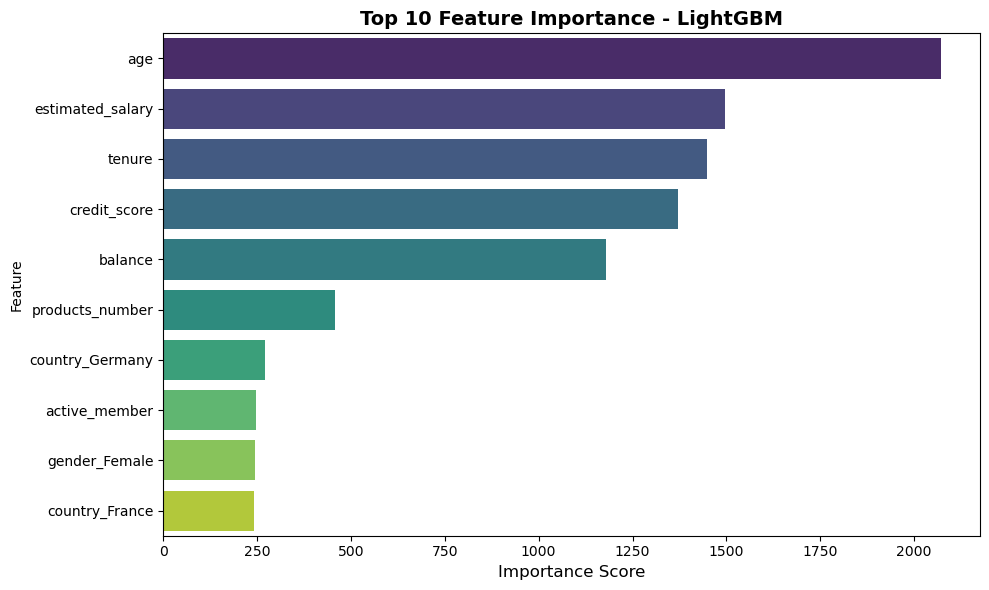


✓ Feature importance extracted!


In [25]:
print("\n" + "=" * 60)
print("STEP 9: FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Extract feature importance from the base LightGBM model
# (The calibrated wrapper doesn't have importances, so we use the underlying model)
feature_importance = lgb_tuned.feature_importances_
feature_names = X_train.columns

# Create a dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature', ax=ax, palette='viridis')
ax.set_title('Top 10 Feature Importance - LightGBM', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✓ Feature importance extracted!")


STEP 10: CONFUSION MATRIX & CLASSIFICATION REPORT

Confusion Matrix:
[[1403  190]
 [ 211 1382]]
  True Negatives: 1403
  False Positives: 190
  False Negatives: 211
  True Positives: 1382


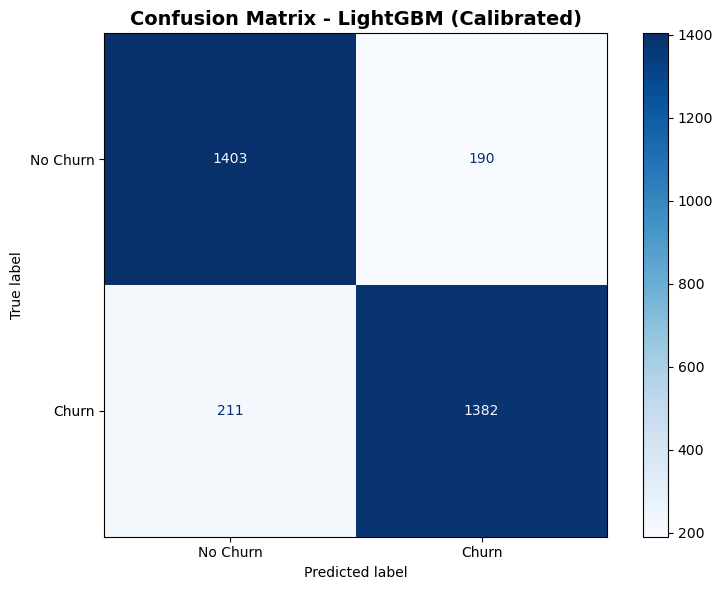


Detailed Classification Report:
              precision    recall  f1-score   support

No Churn (0)       0.87      0.88      0.87      1593
   Churn (1)       0.88      0.87      0.87      1593

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



In [26]:
print("\n" + "=" * 60)
print("STEP 10: CONFUSION MATRIX & CLASSIFICATION REPORT")
print("=" * 60)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred_calibrated)
print("\nConfusion Matrix:")
print(cm)
print(f"  True Negatives: {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives: {cm[1, 1]}")

# Visualize Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix - LightGBM (Calibrated)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_test_pred_calibrated, 
                           target_names=['No Churn (0)', 'Churn (1)']))


STEP 11: ROC CURVE & PROBABILITY DISTRIBUTION


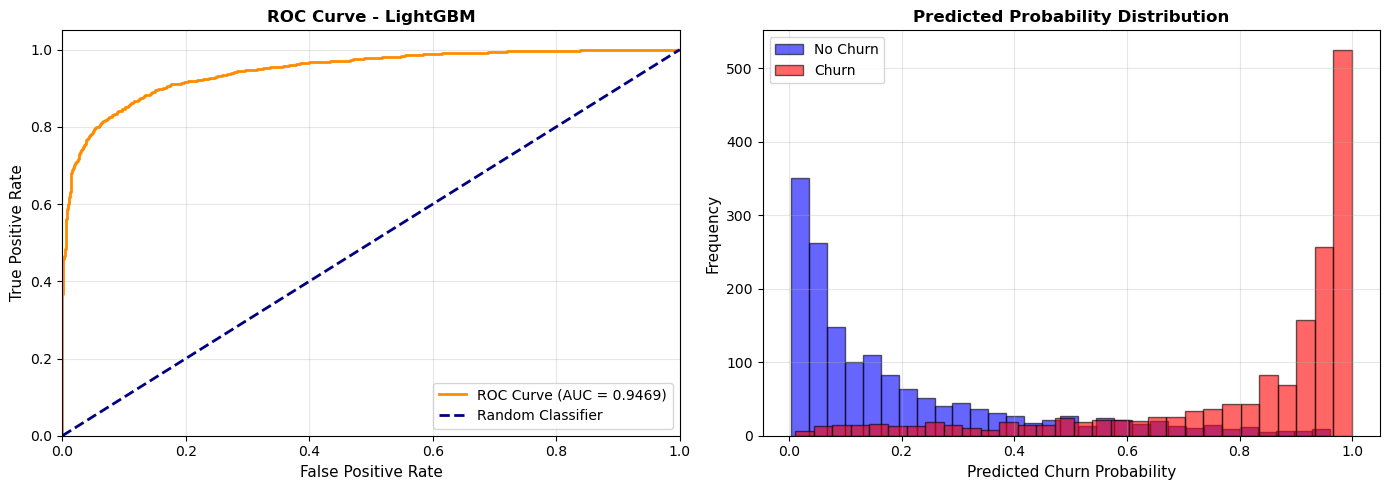


Test ROC-AUC: 0.9469
Mean probability for No Churn: 0.1981
Mean probability for Churn: 0.8152


In [27]:
print("\n" + "=" * 60)
print("STEP 11: ROC CURVE & PROBABILITY DISTRIBUTION")
print("=" * 60)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, best_proba)
roc_auc = auc(fpr, tpr)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curve - LightGBM', fontsize=12, fontweight='bold')
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# Probability Distribution
ax2.hist(best_proba[y_test == 0], bins=30, alpha=0.6, label='No Churn', color='blue', edgecolor='black')
ax2.hist(best_proba[y_test == 1], bins=30, alpha=0.6, label='Churn', color='red', edgecolor='black')
ax2.set_xlabel('Predicted Churn Probability', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Predicted Probability Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTest ROC-AUC: {roc_auc:.4f}")
print(f"Mean probability for No Churn: {best_proba[y_test == 0].mean():.4f}")
print(f"Mean probability for Churn: {best_proba[y_test == 1].mean():.4f}")

In [28]:
print("\n" + "=" * 60)
print("STEP 12: SAVE THE MODEL")
print("=" * 60)

# Save the calibrated model
MODEL_PATH = 'churn_model.joblib'
joblib.dump(best_model, MODEL_PATH)
print(f"✓ Model saved to: {MODEL_PATH}")

# Also save the feature names (needed when you predict new data)
FEATURES_PATH = 'feature_names.joblib'
joblib.dump(list(X_train.columns), FEATURES_PATH)
print(f"✓ Feature names saved to: {FEATURES_PATH}")

# Save importance dataframe for reference
importance_df.to_csv('feature_importance.csv', index=False)
print(f"✓ Feature importance saved to: feature_importance.csv")

print(f"\nModel files ready for Phase 3 (Backend API)!")


STEP 12: SAVE THE MODEL
✓ Model saved to: churn_model.joblib
✓ Feature names saved to: feature_names.joblib
✓ Feature importance saved to: feature_importance.csv

Model files ready for Phase 3 (Backend API)!
